In [1]:
import psycopg2 as pg
import pandas as pd
import math
import numpy as np
import pandas.io.sql as psql

In [2]:
connection = pg.connect("host=localhost dbname=Simulacred user=postgres password=12345678")

In [351]:
connection.close()

In [760]:
serie_pd = psql.read_sql('SELECT * FROM jpcosta.calculo_pd', connection)

In [762]:
probd = serie_pd[['ref', 'porte', 'modalidade', 'pd']]

In [763]:
pd_model = probd[(probd['ref'] > 0) & ((probd['ref'] < 48))].drop('ref', axis=1).groupby(['porte', 'modalidade']).mean().reset_index()
pd_model

,porte,modalidade,pd
0,1,1,0.20434544952723582
1,1,2,0.1376708692589457
2,1,3,0.10355575881584488
3,1,4,0.06293166196415345
4,2,1,0.16559432283245606
5,2,2,0.10554935104276306
6,2,3,0.07228007984606388
7,2,4,0.02892996280999309
8,3,1,0.14034102489771547
9,3,2,0.08601895564877157


In [4]:
pd.options.display.float_format = '{:2}'.format

agg = psql.read_sql('SELECT * FROM jpcosta.perda_obs', connection)

n = agg.ref.max() - 1

n

199

In [26]:
#agg['media'] = agg['saldo']/agg['qtd']
n = 71
a = agg[(agg['nivel_risco'] != 'HH') & (agg.saldo > 0) & (agg.ref == n)].groupby(['porte', 'modalidade']).sum().reset_index()

inad = a['saldo_inad']/a['saldo']

a['inad']  = inad

a['media'] = a['saldo']/a['qtd']

tot = a.qtd.sum()
a['perc'] = a.qtd/tot

a = a[['porte', 'modalidade', 'media', 'saldo', 'inad', 'qtd', 'perc']]#[a['modalidade'] == 1]

a.to_csv(path_or_buf='result_sim2.csv', sep=';', index=False, encoding='latin1')

In [775]:
hst = agg[agg['nivel_risco'] != 'HH'][['ref', 'porte', 'modalidade', 'saldo', 'saldo_inad', 'qtd', 'nivel_risco']].groupby(['ref', 'porte','modalidade', 'nivel_risco']).sum().reset_index()

In [776]:
hst['prov'] = hst['nivel_risco'].map(dict_prov)*hst['saldo']

In [777]:
hst

,ref,porte,modalidade,nivel_risco,saldo,saldo_inad,qtd,prov
0,0,1,1,A,3533.16,0.0,1,17.6658
1,0,1,1,B,38797.7,0.0,11,387.977
2,0,1,1,C,585028.29,0.0,162,17550.848700000002
3,0,1,2,A,4282.42,0.0,2,21.412100000000002
4,0,1,2,B,135317.6,0.0,61,1353.1760000000002
...,...,...,...,...,...,...,...,...
17603,103,6,4,A,21390575.91,0.0,65,106952.87955
17604,103,6,4,AA,23787900.87,0.0,69,0.0
17605,103,6,4,D,9879416.32,0.0,33,987941.6320000001
17606,103,6,4,E,97743.04,97743.03675982638,1,29322.911999999997


In [778]:
df = hst[['ref', 'saldo','prov','saldo_inad']].groupby('ref').sum()

df['iprov'] = df['prov']/df['saldo']
df['inad90'] = df['saldo_inad']/df['saldo']

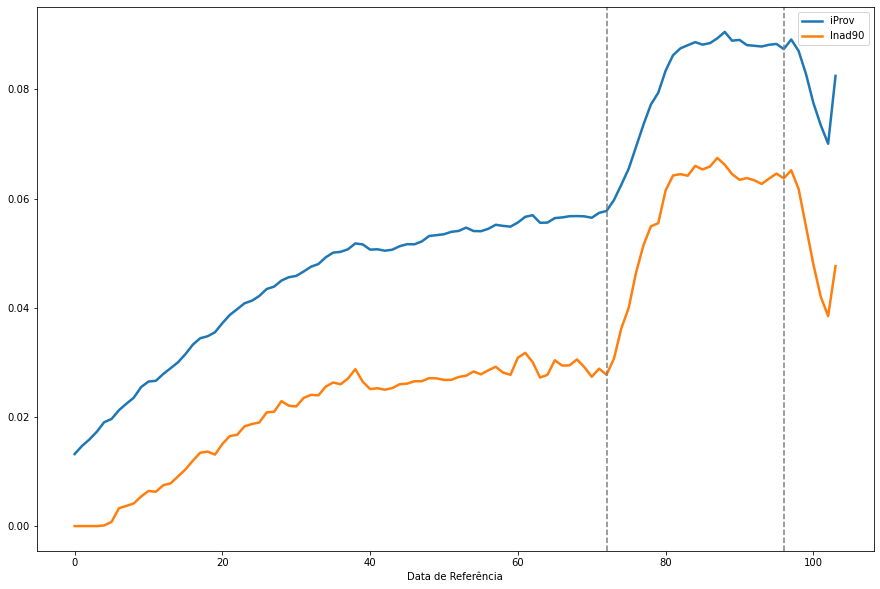

In [779]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(figsize=(15,10))
# data to create an example data frame
#df  = hst[['ref','iprov','inad90']].groupby('ref').sum()#[60:n-82]

# this is to plot the kde
#sns.lineplot(data=df[:100], x='ref', y = 'iPE', label='iPE')
sns.lineplot(data=df, x='ref', y = 'iprov', label='iProv', linewidth=2.5)
sns.lineplot(data=df, x='ref', y = 'inad90', label='Inad90', linewidth=2.5)
#sns.lineplot(data=df[:50], x='ref', y = 'perda_obs', label='PO')

ax.axvline(72, ls='--', c='grey')
ax.axvline(96, ls='--', c='grey')

# beautifying the labels
plt.xlabel('Data de Referência')
plt.ylabel('')
plt.show()

In [650]:
filtro = hst[(hst['porte']==1) & (hst['modalidade']==2)].reset_index()
media = filtro['saldo']/filtro['qtd']
filtro['media'] = media

<AxesSubplot:>

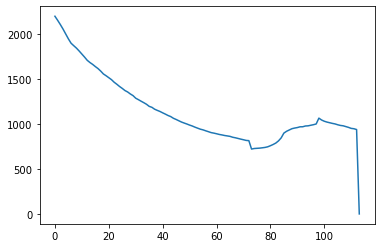

In [651]:
filtro['media'].plot()

In [652]:
b = agg[(agg['nivel_risco'] != 'HH') & (agg.saldo > 0) & (agg.ref == n)].groupby(['nivel_risco']).sum().reset_index()

In [653]:
b['perc_nivel'] = b['saldo']/ b['saldo'].sum()

In [654]:
b

,nivel_risco,ref,porte,modalidade,estagio,qtd,saldo,saldo_inad,perda_att,perc_nivel
0,A,1656,83,56,23,6472,124779553.88,0.0,0.0,0.16832701467800706
1,AA,360,28,15,5,98,25995496.41,0.0,0.0,0.035067798927829845
2,B,1440,60,50,20,14459,163403974.24,0.0,0.0,0.22043117093360431
3,C,2160,105,66,36,53137,224830182.99999997,0.0,0.0,0.303294829458161
4,D,3384,162,117,70,44646,182545950.24999994,0.0,0.0,0.24625360398942378
5,E,1440,62,46,60,3658,5172272.04,5172272.045885835,0.0,0.0069773699658600315
6,F,1584,75,52,66,2519,3803124.6899999995,3803124.7080734703,0.0,0.005130396812698727
7,G,1368,63,42,57,1937,2916122.5300000003,2916122.527808238,0.0,0.003933835188914343
8,H,1440,64,45,60,7157,7845825.049999999,7757118.674001472,0.0,0.010583980045500908


In [655]:
dict_prov = {  'AA': 0.00,
               'A' : 0.005,
               'B':  0.01,
               'C':  0.03,
               'D':  0.10,
               'E':  0.30,
               'F':  0.50,
               'G':  0.70,
               'H':  1.00,
               'HH': 0.00}   

In [656]:
b['prov'] = b['nivel_risco'].map(dict_prov)*b['saldo']

In [657]:
b['prov'].sum()/b['saldo'].sum()

0.0547662261392616

In [658]:
b['saldo_inad'].sum()/b['saldo'].sum()

0.026505917570151662

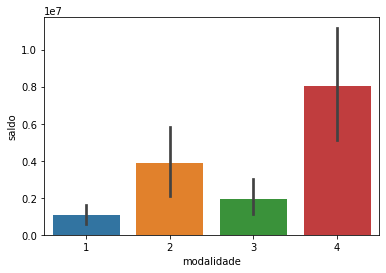

In [659]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(x="modalidade", y="saldo", data=agg[(agg.nivel_risco != 'HH') & (agg.ref==n)])

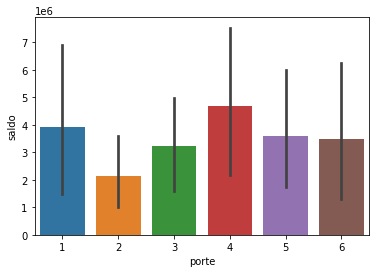

In [660]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(x="porte", y="saldo", data=agg[(agg.nivel_risco != 'HH') & (agg.ref==n)])